In [ ]:
# Imported Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches
import time

# Classifier Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import collections


# Other Libraries
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.metrics import classification_report_imbalanced
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report
from collections import Counter
from sklearn.model_selection import KFold, StratifiedKFold
import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("../data/raw/creditcard.csv")
# C:\Users\Ali A\Desktop\credit-card-fraud-detection\data\raw\creditcard.csv
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
no_of_null_values = df.isnull().sum().max()
print(no_of_null_values)

0


In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [ ]:
# What data type are the actual values stored inside each column?
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [ ]:
# Check class imbalance
no_frauds_pct = round(df['Class'].value_counts()[0]/len(df) * 100, 2)
frauds_pct = round(df['Class'].value_counts()[1]/len(df) * 100, 2)
print(f'No Frauds: {no_frauds_pct}% of the dataset')
print(f'Frauds: {frauds_pct}% of the dataset')


No Frauds: 99.83% of the dataset
Frauds: 0.17% of the dataset


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

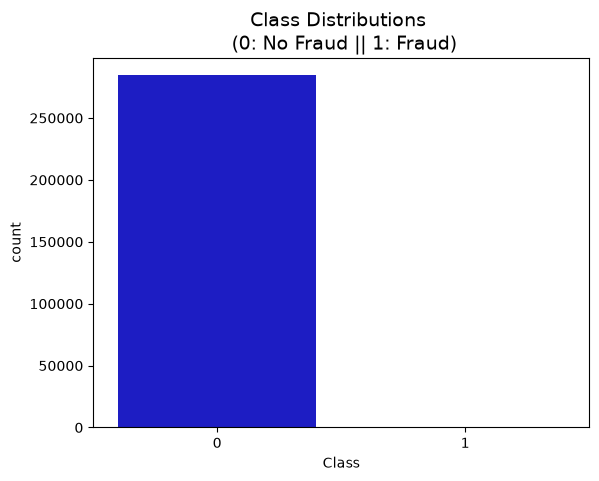

In [ ]:
colours = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df, palette=colours)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

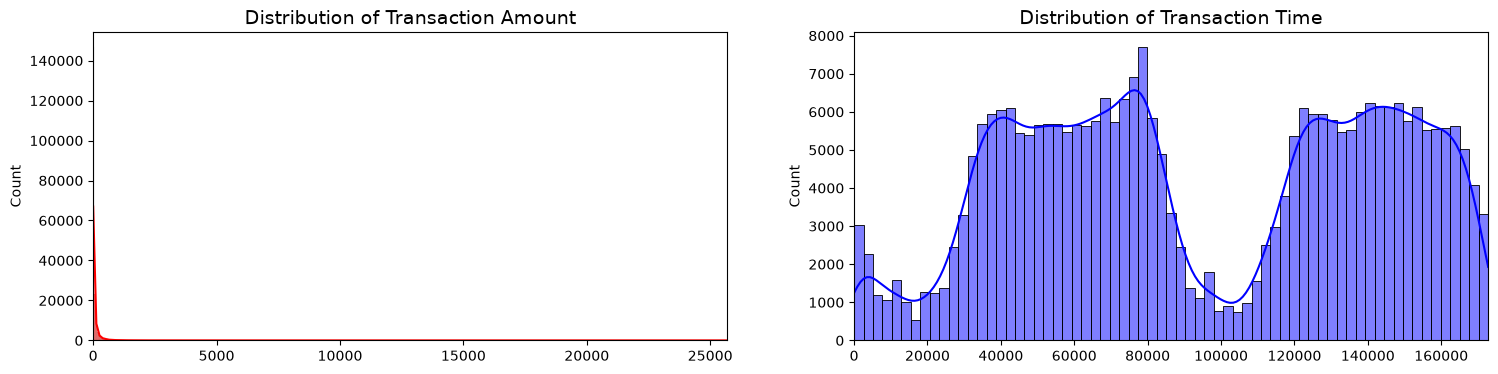

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.histplot(amount_val, ax=ax[0], color='r', kde=True)
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.histplot(time_val, ax=ax[1], color='b', kde=True)
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

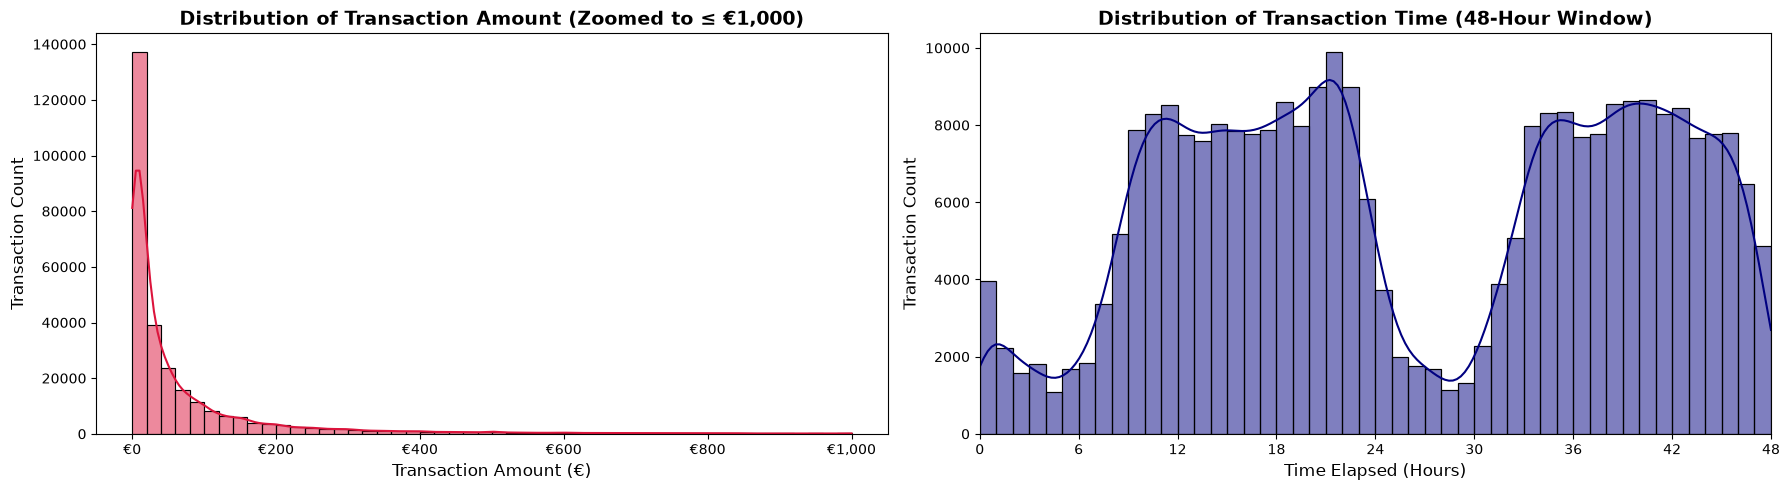

In [ ]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Transaction Amount (Zoomed into <= $1,000 for realistic inspection)
# We plot the bulk of the data (99th percentile) to see the actual shape, not empty space
sns.histplot(df[df['Amount'] <= 1000]['Amount'], ax=ax[0], color='crimson', kde=True, bins=50)
ax[0].set_title('Distribution of Transaction Amount (Zoomed to ≤ €1,000)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Transaction Amount (€)', fontsize=12)
ax[0].set_ylabel('Transaction Count', fontsize=12)
ax[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('€{x:,.0f}'))

# Plot 2: Transaction Time converted into Hours (0 to 48 Hours)
time_in_hours = df['Time'] / 3600

sns.histplot(time_in_hours, ax=ax[1], color='navy', kde=True, bins=48)
ax[1].set_title('Distribution of Transaction Time (48-Hour Window)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Time Elapsed (Hours)', fontsize=12)
ax[1].set_ylabel('Transaction Count', fontsize=12)
ax[1].set_xlim([0, 48])
ax[1].xaxis.set_major_locator(ticker.MultipleLocator(6)) # Tick marks every 6 hours

plt.tight_layout()
plt.show()

## Why Create a Balanced Sub-Sample (50/50 Under-Sampling)?

In the original dataset, legitimate transactions make up **99.83%** ($284,315$ cases) while fraud accounts for only **0.17%** ($492$ cases).

Training machine learning models directly on this extreme distribution introduces two catastrophic failure points:

---

### 1. The Overfitting / Lazy Classifier Problem (The Accuracy Paradox)
* **What happens:** Machine learning loss functions minimize overall error across all rows.
* **The failure:** When $99.83\%$ of the samples belong to Class $0$, a model can achieve a near-perfect **99.83% accuracy** simply by predicting *"Legitimate"* for every single transaction.
* **The consequence:** The algorithm misses $100\%$ of actual fraud cases ($0\%$ Recall) and never learns the subtle multidimensional features ($V1 \dots V28$) that distinguish fraud.

---

### 2. Distorted & Masked Feature Correlations
* **What happens:** Calculating Pearson correlation ($r$) on the original dataset causes the massive majority class ($284,315$ points) to completely drown out feature variance tied to the minority class ($492$ points).
* **The failure:** High-risk indicators will appear to have a correlation near $0.00$ simply because fraudulent patterns are buried under a statistical tidal wave of legitimate transactions.
* **The consequence:** By extracting a **50/50 balanced sub-sample** ($492$ legitimate transactions paired with $492$ fraud transactions), we force the correlation matrix to evaluate both outcomes with equal weight. This unmasks the true positive and negative correlations across features ($V1 \dots V28$).

---

> ⚠️ **Data Science Golden Rule (Avoiding Data Leakage):**
> A balanced sub-sample or resampled distribution is used **only to train models and visualize feature interactions**. The final testing and validation MUST always occur on the **untouched, imbalanced test set** to evaluate realistic real-world production performance.

In [ ]:
# 1. Shuffle the full dataset to ensure rows are randomised
df = df.sample(frac=1, random_state=42)

# 2. Extract all 492 fraud cases
fraud_df = df.loc[df['Class'] == 1]

# 3. Randomly select exactly 492 non-fraud cases
non_fraud_df = df.loc[df['Class'] == 0][:492]

# 4. Concatenate both subsets into a 50/50 sub-sample (984 rows total)
normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# 5. Shuffle the sub-sample rows again
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
146884,87941.0,2.054361,-0.122642,-1.245717,0.189567,0.132497,-0.620765,0.059581,-0.148058,0.338940,...,-0.271204,-0.687048,0.271569,-0.497120,-0.270115,0.208619,-0.076075,-0.075428,0.99,0
95597,65385.0,-2.923827,1.524837,-3.018758,3.289291,-5.755542,2.218276,-0.509995,-3.569444,-1.016592,...,-0.511657,-0.122724,-4.288639,0.563797,-0.949451,-0.204532,1.510206,-0.324706,1354.25,1
96768,65927.0,0.955253,-0.833374,0.847147,0.725970,-1.322868,-0.238842,-0.565347,0.022443,-0.762247,...,-0.110554,-0.129397,-0.040892,0.364872,0.204756,-0.304578,0.055908,0.062489,156.00,0
75511,56098.0,-1.229669,1.956099,-0.851198,2.796987,-1.913977,-0.044934,-1.340739,-0.555548,-1.184468,...,1.208054,0.277612,0.019266,0.508529,-0.201183,-0.249600,0.562239,0.075309,170.92,1
255556,157284.0,-0.242245,4.147186,-5.672349,6.493741,1.591168,-1.602523,-0.950463,0.722903,-4.128505,...,0.249023,-0.480286,-0.286080,-1.153575,-0.035571,0.559628,0.409446,0.221048,0.77,1


In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# RobustScaler is less prone to extreme financial outliers
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop the raw unscaled columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Shift scaled columns to the front of the DataFrame
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']

df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

# Verify the changes
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
43428,4.781527,-0.507372,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,...,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,1
49906,6.960386,-0.474994,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,...,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,0
29474,0.125760,-0.578108,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,...,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,0
276481,-0.286453,0.968421,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,...,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,0
278846,-0.294977,0.984281,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,...,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0


In [ ]:
# splitting the dataset into features and target variable
# y is the target variable (Class) and X is the feature set (all other columns)
y = df['Class']
X = df.drop(['Class'], axis=1)
# axis=1 drops a column and axis=0 drops the row

In [ ]:
print(X, y)